In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from scipy.signal import find_peaks

In [122]:
base_folder = "./StepperMotorCalibration/"

# Get all numeric subfolders
subfolders = sorted([f for f in os.listdir(base_folder) if f.isdigit()], key=lambda x: int(x))


specs = []
for sub in subfolders:
    print(sub)
    folder_path = os.path.join(base_folder, sub)
    files = glob.glob(folder_path + "/*.dat")

    sub_data = []
    for f in files:
        df = pd.read_csv(f, sep=r"\s+", header=None)
        df.columns = ['x', 'y']
        sub_data.append(df["y"].values)
    sub_data = np.mean(sub_data, axis = 0)

    specs.append(sub_data)

x_array = df["x"].values

0
200
400
600
800
1000
1200
1400
1600
1800
2000


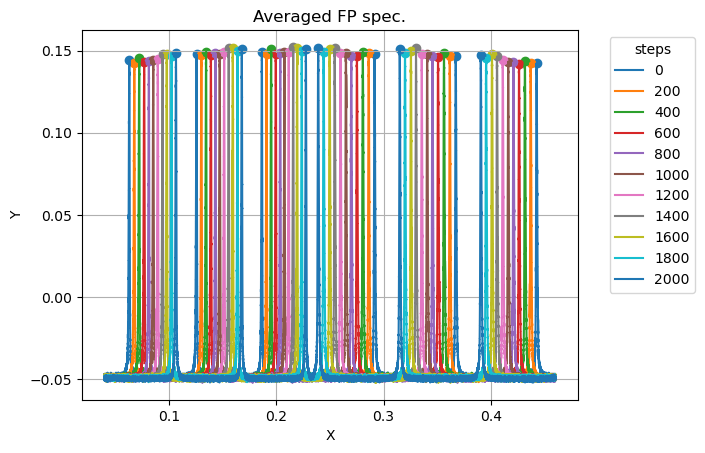

In [153]:
slice = 20000

peaks_list = []
for id, sub in enumerate(subfolders):
    plt.plot(x_array[slice:-slice], specs[id][slice:-slice], label = sub)
    peaks, props = find_peaks(specs[id][slice:-slice], height=0.1, distance=2000)
    plt.scatter(x_array[slice:-slice][peaks],specs[id][slice:-slice][peaks])
    peaks_list.append(peaks)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Averaged FP spec.")
plt.legend(title="steps",bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()

In [227]:
peaks_positions = x_array[peaks_list]
positions_moves = peaks_positions - peaks_positions[0]
print(positions_moves)

peak_spacing = np.diff(peaks_positions,axis = 1)
print(peak_spacing)

peak_spacing_mean = np.mean(peak_spacing,axis = 0)
print(peak_spacing_mean)

[[ 0.        0.        0.        0.        0.        0.      ]
 [ 0.004724  0.004494  0.004358 -0.005454 -0.0055   -0.005532]
 [ 0.00927   0.008858  0.008642 -0.010912 -0.01091  -0.01087 ]
 [ 0.013916  0.013368  0.012996 -0.016414 -0.016408 -0.016368]
 [ 0.018244  0.017606  0.01716  -0.02168  -0.021664 -0.021554]
 [ 0.022352  0.02159   0.021044 -0.026682 -0.026636 -0.026456]
 [ 0.026594  0.025726  0.025014 -0.031726 -0.03167  -0.031496]
 [ 0.031082  0.029958  0.029216 -0.037092 -0.037004 -0.03687 ]
 [ 0.034932  0.033752  0.032886 -0.041888 -0.041692 -0.041538]
 [ 0.039452  0.03819   0.03715  -0.0474   -0.047252 -0.04701 ]
 [ 0.043522  0.042142  0.041022 -0.052452 -0.052152 -0.051984]]
[[0.062682 0.060838 0.104946 0.075612 0.075348]
 [0.062452 0.060702 0.095134 0.075566 0.075316]
 [0.06227  0.060622 0.085392 0.075614 0.075388]
 [0.062134 0.060466 0.075536 0.075618 0.075388]
 [0.062044 0.060392 0.066106 0.075628 0.075458]
 [0.06192  0.060292 0.05722  0.075658 0.075528]
 [0.061814 0.06012

In [229]:
effective_spacings = peak_spacing_mean[[0,1,-2,-1]]
print(effective_spacing)

effective_moves = positions_moves[:,[0,1,-2,-1]]
print(effective_moves)

FSR = 375e3 #kHz

freq_changes = effective_moves/effective_spacings * FSR
print(freq_changes)

[0.061918   0.06027473 0.07568582 0.075458  ]
[[ 0.        0.        0.        0.      ]
 [ 0.004724  0.004494 -0.0055   -0.005532]
 [ 0.00927   0.008858 -0.01091  -0.01087 ]
 [ 0.013916  0.013368 -0.016408 -0.016368]
 [ 0.018244  0.017606 -0.021664 -0.021554]
 [ 0.022352  0.02159  -0.026636 -0.026456]
 [ 0.026594  0.025726 -0.03167  -0.031496]
 [ 0.031082  0.029958 -0.037004 -0.03687 ]
 [ 0.034932  0.033752 -0.041692 -0.041538]
 [ 0.039452  0.03819  -0.047252 -0.04701 ]
 [ 0.043522  0.042142 -0.052152 -0.051984]]
[[      0.               0.               0.               0.        ]
 [  28610.42030462   27959.47954597  -27250.81203783  -27492.11488839]
 [  56142.80191021   55110.16239836  -54055.70169687  -54020.11728793]
 [  84280.82323436   83169.18553063  -81296.60434851  -81343.26400818]
 [ 110492.9102535   109535.95774154 -107338.47127048 -107115.87930305]
 [ 135372.58989181  134322.46564344 -131973.20535268 -131477.1129317 ]
 [ 161063.82675299  160054.64352554 -156915.12991148 -

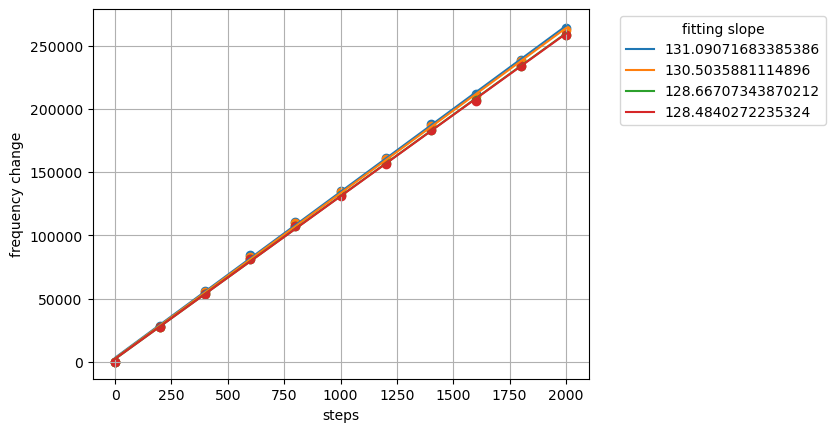

In [231]:
# plt.scatter(subfolders, abs(freq_changes))
for i in range(4):
    stepper_range = np.array(subfolders).astype(int)
    plt.scatter(stepper_range,abs(freq_changes[:,i]))
    a, b = np.polyfit(stepper_range, abs(freq_changes[:,i]), 1)
    plt.plot(stepper_range,a*stepper_range+b, label = f"{a}")

plt.ylabel("frequency change")
plt.xlabel("steps")
plt.legend(title="fitting slope",bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)

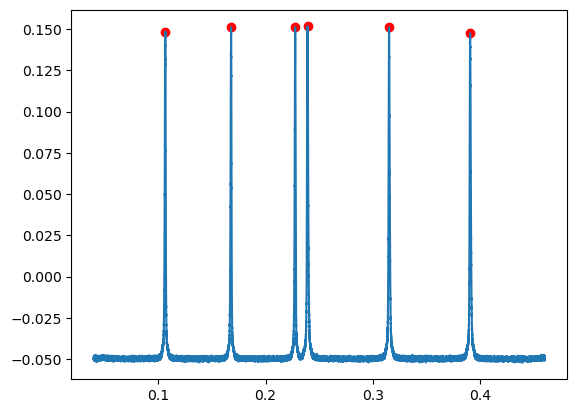

In [139]:
id = -1
slice = 20000
plt.plot(x_array[slice:-slice],specs[id][slice:-slice],label = subfolders[id])


peaks, props = find_peaks(specs[id][slice:-slice], height=0.1, distance=2000)

plt.scatter(x_array[slice:-slice][peaks],specs[id][slice:-slice][peaks],c="r")